# Study how calorimeter decay shower truth is processed

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
from utils import load_root_file
from edm4hep_utils import build_calo_df, build_particle_df, build_tracker_df, load_edm4hep_file
from clustering_metrics import evaluate_clustering, plot_clustering_metrics
from particle_decay_tree import build_decay_tree, process_decay_tree, visualize_decay_tree, analyze_particle_flow, run_decay_tree_analysis, visualize_highlights, interactive_decay_tree
from viz_utils import event_diagnostics, plot_particle_distribution

from edm4hep_utils import pixel_readouts, strip_readouts, get_simulator_status_bits
all_tracker_readouts = pixel_readouts + strip_readouts

## Roadmap

1. Load in reglular low threshold edm4hep file
2. Get histogram binned by vz, vr
3. Load in tv handled edm4hep file


## Compare versions

In [1]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pion_10GeV/v1"
event_num = 0

In [4]:
edm4hep_file = f"{base_dir}/single_run_test_low_threshold/edm4hep.root"

v1_event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [10]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pion_10GeV/v2"
event_num = 0

In [11]:
edm4hep_file = f"{base_dir}/single_run_test_low_threshold/edm4hep.root"

v2_event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [12]:
tracker_df_v1 = v1_event["tracker_df"]
tracker_df_v2 = v2_event["tracker_df"]

In [15]:
calo_cells_v1 = v1_event["calo_hits_df"]
calo_cells_v2 = v2_event["calo_hits_df"]


Slightly different - that's a little concerning, but let's deal with it later...

# Single Particle

## 1. Load in base edm4hep file

In [93]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pion_10GeV/v2"
event_num = 4

In [94]:
edm4hep_file = f"{base_dir}/single_run_test_low_threshold/edm4hep.root"

event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [95]:
tracker_df = event["tracker_df"]
tracker_df.columns

Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
       'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [96]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [97]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [98]:
hits_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
0,80783511597926416,0.000236,-691.303101,1069.240845,1463.699951,0,1,1273.254150,1939.998291,2.144733,0.715927,0.983287,ECalBarrelCollection
1,81064986574669840,0.000277,-693.235657,1073.906494,1468.800049,1,2,1278.221680,1947.106689,2.144021,0.716133,0.982973,ECalBarrelCollection
2,81346461551413264,0.000360,-695.168213,1078.572021,1473.900024,2,3,1283.189941,1954.215332,2.143314,0.716337,0.982661,ECalBarrelCollection
3,81627936528156688,0.000243,-697.100708,1083.237671,1479.000000,3,4,1288.158813,1961.324585,2.142613,0.716541,0.982352,ECalBarrelCollection
4,81909411504900112,0.000196,-699.033264,1087.903198,1484.099976,4,5,1293.128296,1968.434326,2.141917,0.716743,0.982044,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,26177198610663443,0.000002,-1050.488403,2065.740723,2790.000000,926,929,2317.500977,3626.969727,2.041244,0.693150,1.018457,HCalBarrelCollection
482,26458690767341587,0.000295,-1219.904541,2161.172119,2820.000000,929,930,2481.699463,3756.491943,2.084677,0.721675,0.974558,HCalBarrelCollection
483,25614270132144147,0.003790,-1228.104004,2102.573730,2730.000000,930,935,2434.965332,3658.135498,2.099439,0.728338,0.964510,HCalBarrelCollection
484,25614265837176851,0.000082,-1200.387695,2114.054443,2730.000000,935,936,2431.081299,3655.551514,2.087213,0.727545,0.965702,HCalBarrelCollection


In [99]:
contrib_df = event["calo_contrib_df"]


In [100]:
contrib_df

,PDG,energy,time,step_x,step_y,step_z,particle_id,detector
0,0,0.000236,6.467867,0.0,0.0,0.0,0,ECalBarrelCollection
1,0,0.000277,6.493701,0.0,0.0,0.0,0,ECalBarrelCollection
2,0,0.000360,6.519507,0.0,0.0,0.0,0,ECalBarrelCollection
3,0,0.000243,6.545238,0.0,0.0,0.0,0,ECalBarrelCollection
4,0,0.000196,6.570945,0.0,0.0,0.0,0,ECalBarrelCollection
...,...,...,...,...,...,...,...,...
932,0,0.000882,12.340579,0.0,0.0,0.0,0,HCalBarrelCollection
933,0,0.000711,12.373006,0.0,0.0,0.0,0,HCalBarrelCollection
934,0,0.000638,12.305313,0.0,0.0,0.0,0,HCalBarrelCollection
935,0,0.000082,12.374341,0.0,0.0,0.0,0,HCalBarrelCollection


In [101]:
# Get contribs and tracker hits
particles_with_hits = np.concatenate([contrib_df.particle_id.unique(), tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits

array([0, 2], dtype=int32)

In [102]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1400,    # in mm
    'tracking_z_max': 3400,     # in mm
    'energy_threshold': 1.0     # in GeV
}


In [103]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max'])]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi


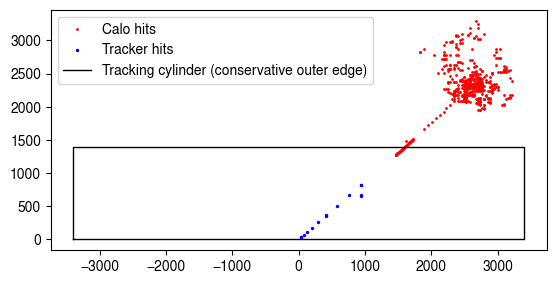

In [104]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


In [45]:
particles_df.loc[particles_with_hits].vz.describe()

count       4.000000
mean    -2058.149904
std      1593.150317
min     -3424.312206
25%     -3257.444219
50%     -2404.143705
75%     -1204.849390
max         0.000000
Name: vz, dtype: float64

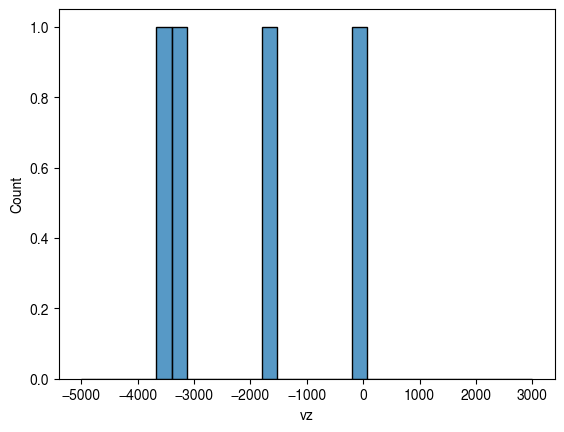

In [46]:
sns.histplot(particles_df.loc[particles_with_hits].vz, bins = 30, binrange=(-5000, 3000))
plt.show()


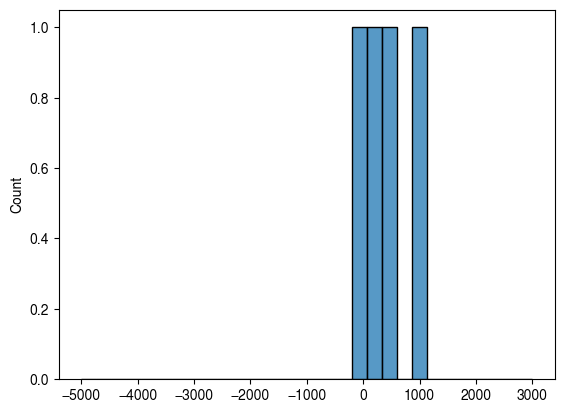

In [47]:
sns.histplot(np.sqrt(particles_df.loc[particles_with_hits].vx**2 + particles_df.loc[particles_with_hits].vy**2), bins = 30, binrange=(-5000, 3000))
plt.show()


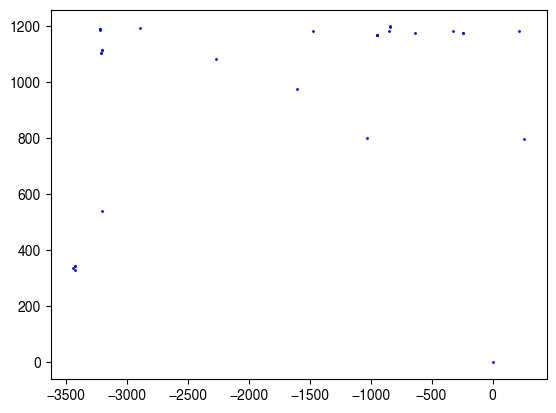

In [48]:
plt.scatter(particles_df.vz, np.sqrt(particles_df.vx**2 + particles_df.vy**2), c="blue", s=1)
plt.show()


## 2. Load in TV handled edm4hep file

In [2]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pion_10GeV/v2"
event_num = 0

In [3]:
edm4hep_file = f"{base_dir}/single_run_test_TV_low_threshold/edm4hep.root"

event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [4]:
tracker_df = event["tracker_df"]
tracker_df.columns

Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
       'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [5]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [6]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [7]:
hits_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
0,18387352939531399184,1.932579e-03,1252.400024,102.000000,-1076.099976,0,1,1256.546753,1654.358154,0.081264,2.278991,-0.776102,ECalBarrelCollection
1,18387352930941497360,2.622566e-03,1257.449951,91.800003,-1076.099976,1,2,1260.796387,1657.588257,0.072876,2.277323,-0.773908,ECalBarrelCollection
2,18443929233756973072,4.704779e-06,1254.039185,403.515839,-56.099998,2,3,1317.360718,1318.554688,0.311310,1.613356,-0.042572,ECalBarrelCollection
3,18353012803394269200,4.001613e-04,1272.599976,-122.400002,-1703.400024,3,16,1278.472778,2129.803711,-0.095886,2.497745,-1.098035,ECalBarrelCollection
4,18439988571198220304,5.001108e-06,1273.891113,395.178131,-127.500000,16,17,1333.778198,1339.858398,0.300800,1.666100,-0.095448,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,18435203565311059987,1.181931e-04,1661.053467,428.256714,-1260.000000,2208,2210,1715.372314,2128.403564,0.252327,2.204326,-0.680729,HCalBarrelCollection
627,18434640632537475091,8.966544e-10,1568.013550,519.605408,-1320.000000,2210,2212,1651.864502,2114.487061,0.319990,2.244987,-0.731963,HCalBarrelCollection
628,18438862817317744659,2.207358e-06,1749.500000,300.000000,-840.000000,2212,2213,1775.035278,1963.759155,0.169826,2.012800,-0.457141,HCalBarrelCollection
629,18439144292294455315,1.975521e-08,1749.500000,300.000000,-810.000000,2213,2218,1775.035278,1951.115112,0.169826,1.998901,-0.441814,HCalBarrelCollection


In [8]:
contrib_df = event["calo_contrib_df"]


# Low Pileup Particle

In [2]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 1.0     # in GeV
}


In [3]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/outputs/decay_testing/low_pileup/"
event_num = 0

## 0. Load in original base edm4hep file

In [68]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/outputs/decay_testing/low_pileup/"
event_num = 0

In [69]:
edm4hep_file = f"{base_dir}/low_threshold_original/edm4hep.root"

event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [70]:
tracker_df = event["tracker_df"]
tracker_df.columns, len(tracker_df)

(Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
        'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
        'detector'],
       dtype='object'),
 22065)

In [71]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [72]:
particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,7000.000000,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457764,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885193,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841492,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382065,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406500,11,0,1493172224,-1.000000,19.541965,0.000511,-299.902636,1145.078819,2991.900520,-0.000953,...,1141.891321,2995.630804,425960,425961,425965,425965,0.002750,0.004253,1.002901,-1.924785
406501,11,0,1493172224,-1.000000,24.605585,0.000511,-821.447430,-263.918514,3208.522889,-0.000823,...,-265.622790,3208.615996,425961,425962,425965,425965,0.003097,0.003221,0.281592,-1.839849
406502,11,0,1493172224,-1.000000,20.544994,0.000511,-485.961906,1084.170673,3200.297544,-0.000461,...,1084.139483,3200.321416,425962,425963,425965,425965,0.001174,0.001435,0.655716,-1.974886
406503,11,0,1493172224,-1.000000,20.208435,0.000511,-223.787133,1091.063616,3215.822788,0.000249,...,1091.005626,3215.876509,425963,425964,425965,425965,0.001502,0.002022,0.809731,-1.404139


In [6]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [7]:
hits_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
0,18314450877613664272,2.416614e-05,1137.549927,526.390564,-2397.000000,0,1,1253.437988,2704.942871,0.433398,2.659778,-1.403731,ECalBarrelCollection
1,18335561230284775440,6.632625e-05,1158.841919,776.580017,-2019.599976,1,2,1394.987915,2454.541748,0.590400,2.537119,-1.165429,ECalBarrelCollection
2,18387071477439805456,7.453639e-05,-1234.614624,384.429535,-1081.199951,2,3,1293.081299,1685.542236,2.839732,2.267190,-0.760642,ECalBarrelCollection
3,74309376680323088,4.671832e-05,1183.535889,468.155792,1341.300049,3,5,1272.763550,1849.057373,0.376670,0.759186,0.918942,ECalBarrelCollection
4,18371871901711632400,2.835334e-07,667.744141,-1078.999268,-1356.599976,5,6,1268.905640,1857.548096,-1.016628,2.389583,-0.929408,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178287,19984762007650580,4.246452e-09,-150.730362,2141.747070,3902.500000,761503,761504,2147.044434,4454.133789,1.641058,0.502975,1.358963,HCalEndcapCollection
178288,19703287030939924,6.907979e-09,-144.877655,2112.323486,3902.500000,761504,761505,2117.285889,4439.865723,1.639276,0.497102,1.371212,HCalEndcapCollection
178289,19140315602813204,3.094865e-04,-280.290009,2024.212769,4106.500000,761505,761507,2043.526245,4586.866211,1.708390,0.461752,1.447883,HCalEndcapCollection
178290,18577369944359188,5.468227e-05,-239.161041,1971.218384,4106.500000,761507,761508,1985.673706,4561.385742,1.691533,0.450396,1.473667,HCalEndcapCollection


In [8]:
contrib_df = event["calo_contrib_df"]


In [9]:
contrib_df

,PDG,energy,time,step_x,step_y,step_z,particle_id,detector
0,0,2.416614e-05,312.383392,0.0,0.0,0.0,8352,ECalBarrelCollection
1,0,6.632625e-05,120.258148,0.0,0.0,0.0,8455,ECalBarrelCollection
2,0,7.453639e-05,7668.329590,0.0,0.0,0.0,8592,ECalBarrelCollection
3,0,2.974118e-05,7679.745117,0.0,0.0,0.0,8592,ECalBarrelCollection
4,0,1.697715e-05,7679.745605,0.0,0.0,0.0,8592,ECalBarrelCollection
...,...,...,...,...,...,...,...,...
761504,0,6.907979e-09,4799.214355,0.0,0.0,0.0,1754,HCalEndcapCollection
761505,0,2.598804e-04,24.107910,0.0,0.0,0.0,1754,HCalEndcapCollection
761506,0,4.960612e-05,24.099184,0.0,0.0,0.0,1754,HCalEndcapCollection
761507,0,5.468227e-05,24.303453,0.0,0.0,0.0,1754,HCalEndcapCollection


In [10]:
# Get contribs and tracker hits
particles_with_hits = np.concatenate([contrib_df.particle_id.unique(), tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits

array([    80,     82,     83, ..., 406477, 406478, 406480], dtype=int32)

In [12]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max'])]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
431,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.135754,...,3357.657613,-10000.000000,913,914,1489,1489,0.169181,0.462928,-1.664549,2.502134
432,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.028816,...,4744.760131,-10000.000000,914,915,1489,1489,0.130022,0.214030,-1.083045,1.794279
1367,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.269879,...,586.835441,2048.408574,4509,4510,6891,6891,0.323424,0.705943,1.416553,2.557915
1368,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.485722,...,551.727384,2048.297976,4510,4511,6891,6893,0.502281,1.020187,1.334736,2.884102
1369,22,1,83886080,0.0,15.535490,0.000000,-1057.864047,753.356960,1686.353161,-0.804957,...,753.633764,1686.899704,4511,4512,6893,6893,1.049465,1.693831,1.058093,2.444975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406500,11,0,1493172224,-1.0,19.541965,0.000511,-299.902636,1145.078819,2991.900520,-0.000953,...,1141.891321,2995.630804,425960,425961,425965,425965,0.002750,0.004253,1.002901,-1.924785
406501,11,0,1493172224,-1.0,24.605585,0.000511,-821.447430,-263.918514,3208.522889,-0.000823,...,-265.622790,3208.615996,425961,425962,425965,425965,0.003097,0.003221,0.281592,-1.839849
406502,11,0,1493172224,-1.0,20.544994,0.000511,-485.961906,1084.170673,3200.297544,-0.000461,...,1084.139483,3200.321416,425962,425963,425965,425965,0.001174,0.001435,0.655716,-1.974886
406503,11,0,1493172224,-1.0,20.208435,0.000511,-223.787133,1091.063616,3215.822788,0.000249,...,1091.005626,3215.876509,425963,425964,425965,425965,0.001502,0.002022,0.809731,-1.404139


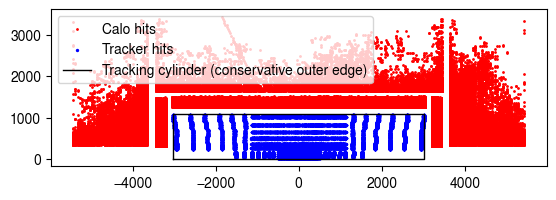

In [13]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


In [14]:
# Ensure all tracker hits are within the tracking cylinder
(((tracker_df.x**2 + tracker_df.y**2) < detector_params['tracking_radius']**2) & (tracker_df.z < detector_params['tracking_z_max'])).all()


np.True_

In [15]:
# Ensure all calo hits are outside the tracking cylinder
(((hits_df.x**2 + hits_df.y**2) > detector_params['tracking_radius']**2) | (hits_df.z.abs() > detector_params['tracking_z_max'])).all()

np.True_

In [16]:
particles_df.loc[particles_with_hits].vz.describe()

count    76481.000000
mean       868.510206
std       3139.073252
min      -4470.397421
25%      -3241.963306
50%       3233.606321
75%       3298.410235
max       5068.045100
Name: vz, dtype: float64

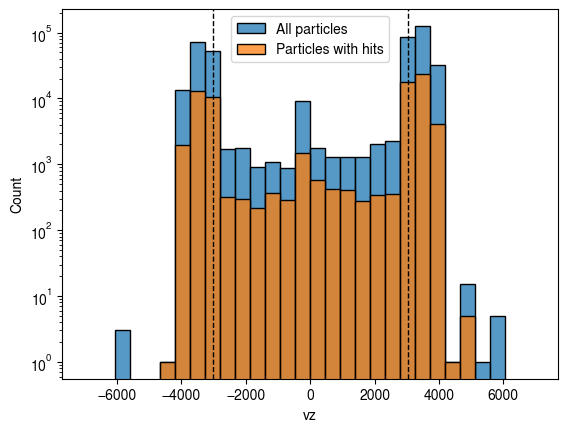

In [24]:
sns.histplot(particles_df.vz, bins = 30, binrange=(-7000, 7000), label="All particles")
sns.histplot(particles_df.loc[particles_with_hits].vz, bins = 30, binrange=(-7000, 7000), label="Particles with hits")
plt.axvline(detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.axvline(-detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


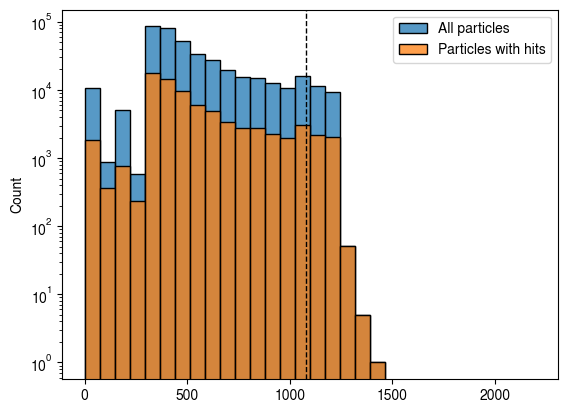

In [25]:
sns.histplot(np.sqrt(particles_df.vx**2 + particles_df.vy**2), bins = 30, binrange=(0, 2200), label="All particles")
sns.histplot(np.sqrt(particles_df.loc[particles_with_hits].vx**2 + particles_df.loc[particles_with_hits].vy**2), bins = 30, binrange=(0, 2200), label="Particles with hits")
plt.axvline(detector_params['tracking_radius'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


## 1. Load in new base edm4hep file

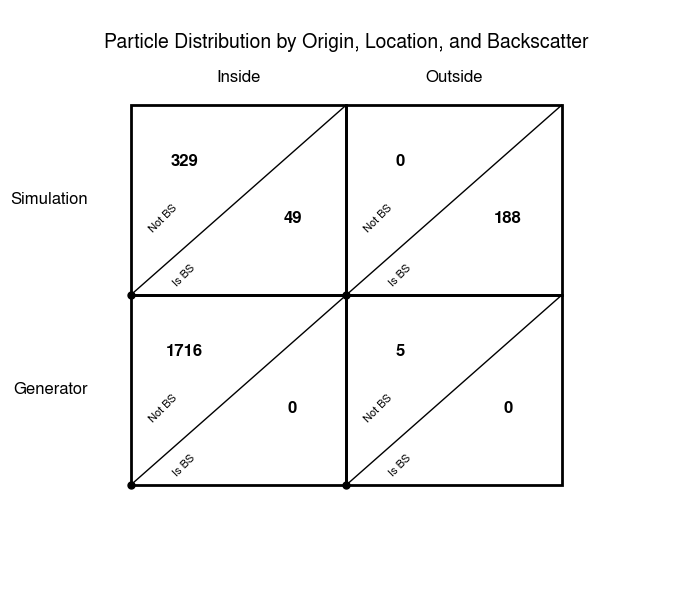

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1716 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |           329 |         49
Outside   | Simulation |             0 |        188

Totals by Category:
Total particles: 2287
From Generator: 1721
From Simulation: 566
Inside Tracker: 2094
Outside Tracker: 193
Backscatter: 237


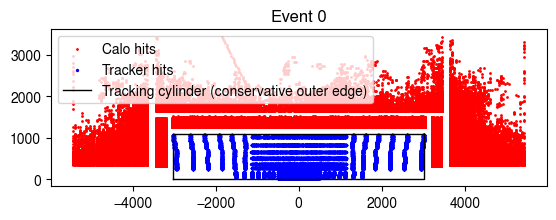

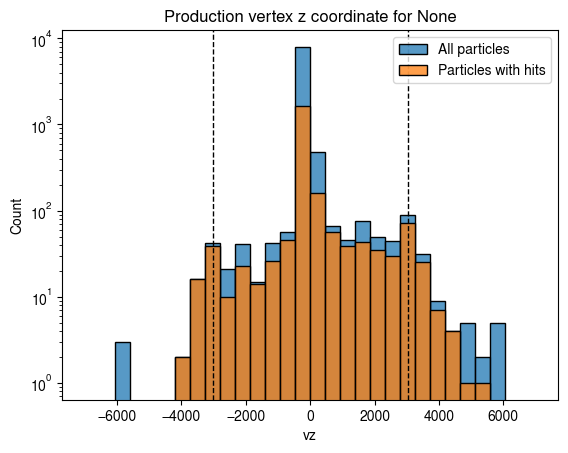

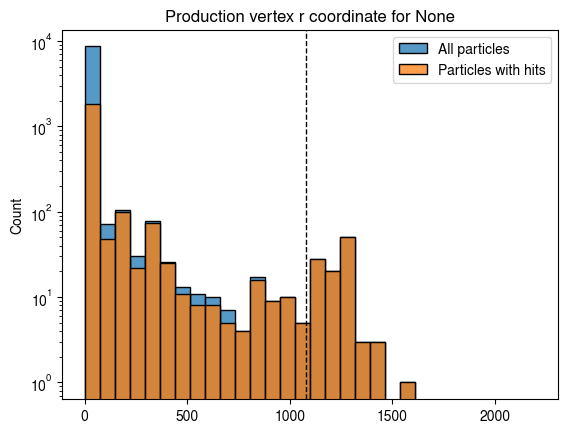

In [6]:
edm4hep_file = f"{base_dir}/low_threshold/edm4hep.root"
event = event_diagnostics(edm4hep_file, event_num=event_num, detector_params=detector_params)

In [101]:
tracker_df = event["tracker_df"]
tracker_df.columns

Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
       'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [102]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [103]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [104]:
contrib_df = event["calo_contrib_df"]


In [105]:
# Get contribs and tracker hits
particles_with_hits = np.concatenate([contrib_df.particle_id.unique(), tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits

array([  81,   82,   83, ..., 9128, 9129, 9130], dtype=int32)

In [106]:
particles_with_hits = particles_df.loc[particles_with_hits]

In [107]:
particles_with_hits["created_in_simulation"] = particles_with_hits.simulatorStatus.apply(lambda x: get_simulator_status_bits(x)["created_in_simulation"]).astype(int)
particles_with_hits["backscatter"] = particles_with_hits.simulatorStatus.apply(lambda x: get_simulator_status_bits(x)["backscatter"]).astype(int)
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_with_hits["created_outside_tracker"] = ((particles_with_hits.vx**2 + particles_with_hits.vy**2) > detector_params['tracking_radius']**2) | (particles_with_hits.vz > detector_params['tracking_z_max']).astype(int)

In [108]:
particles_with_hits

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,parents_end,daughters_begin,daughters_end,pt,p,eta,phi,created_in_simulation,backscatter,created_outside_tracker
81,-2112,1,150994944,0.0,8.091558,0.939570,0.003543,-0.005813,-105.372111,0.253307,...,89,233,234,0.267853,1.071615,-2.063633,-0.331065,0,0,False
82,-211,1,134217728,-1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,-0.166478,...,91,234,234,0.207967,0.704552,-1.890799,2.498928,0,0,False
83,211,1,83886080,1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,-0.183526,...,93,234,234,0.490934,2.525152,2.321307,1.953931,0,0,False
85,-321,1,134217728,-1.0,8.091558,0.493680,0.003543,-0.005813,-105.372111,-0.520439,...,97,235,236,0.555004,7.124353,3.243925,-2.786807,0,0,False
92,-211,1,150994944,-1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,0.079074,...,109,253,253,0.088126,0.113962,0.748153,-0.457230,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9126,22,0,1157627904,0.0,9.741179,0.000000,-33.028815,199.675936,345.805936,0.314472,...,28587,28589,28590,2.669785,5.412661,1.332622,1.452733,1,0,False
9127,22,0,2030043136,0.0,21.632509,0.000000,-539.536353,483.901875,3201.495043,0.000127,...,28588,28590,28590,0.000328,0.000511,-1.013309,-1.172824,1,1,True
9128,11,0,1157627904,-1.0,9.625705,0.000511,-26.683532,169.692869,321.268177,-0.113812,...,28589,28590,28591,0.733771,1.964268,1.640957,1.726531,1,0,False
9129,11,0,2030043136,-1.0,19.328438,0.000511,-454.786562,1165.726570,3018.535546,0.000587,...,28590,28591,28591,0.003817,0.012957,1.892916,1.416392,1,1,True


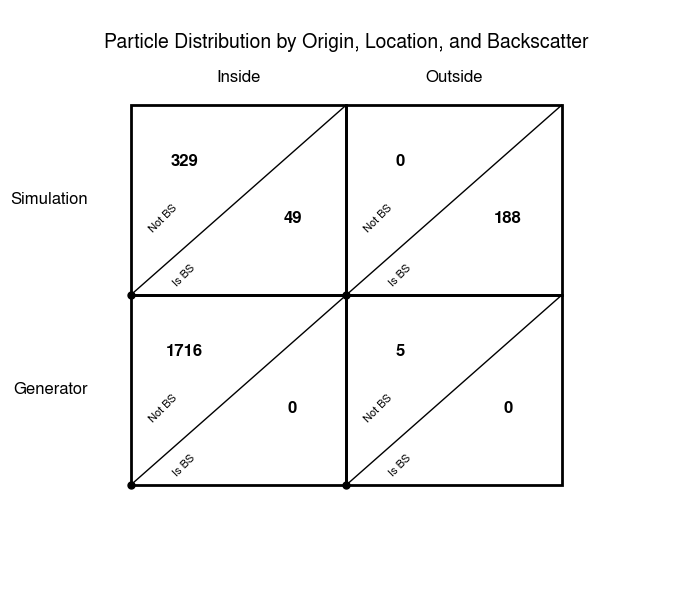

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1716 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |           329 |         49
Outside   | Simulation |             0 |        188

Totals by Category:
Total particles: 2287
From Generator: 1721
From Simulation: 566
Inside Tracker: 2094
Outside Tracker: 193
Backscatter: 237


In [109]:
# Call the function with the current DataFrame
plot_particle_distribution(particles_with_hits)

In [110]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max'])]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
431,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.135754,...,3357.657613,-10000.000000,913,914,1043,1043,0.169181,0.462928,-1.664549,2.502134
432,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.028816,...,4744.760131,-10000.000000,914,915,1043,1043,0.130022,0.214030,-1.083045,1.794279
1367,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.269879,...,586.819899,2048.353858,4509,4510,4782,4782,0.323424,0.705943,1.416553,2.557915
1368,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.485722,...,547.870862,2021.524967,4510,4511,4782,4782,0.502281,1.020187,1.334736,2.884102
1369,22,1,83886080,0.0,15.535490,0.000000,-1057.864047,753.356960,1686.353161,-0.804957,...,757.137901,1693.818546,4511,4512,4782,4782,1.049465,1.693831,1.058093,2.444975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9119,2212,0,2030043136,1.0,18.847214,0.938272,-272.137866,1251.617539,2851.319139,0.118233,...,658.987241,2242.344725,28579,28580,28589,28589,0.495659,0.592931,-0.616677,-1.329937
9120,2112,0,2013265920,0.0,31.043116,0.939565,-240.135307,1149.269292,3240.537294,0.002847,...,381.543123,1350.000000,28580,28581,28589,28589,0.013168,0.013823,0.313994,1.352887
9127,22,0,2030043136,0.0,21.632509,0.000000,-539.536353,483.901875,3201.495043,0.000127,...,296.344487,-2542.609208,28587,28588,28590,28590,0.000328,0.000511,-1.013309,-1.172824
9129,11,0,2030043136,-1.0,19.328438,0.000511,-454.786562,1165.726570,3018.535546,0.000587,...,907.034224,2643.817965,28589,28590,28591,28591,0.003817,0.012957,1.892916,1.416392


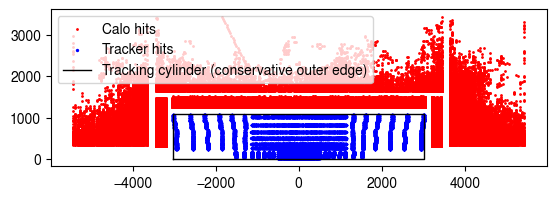

In [111]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


In [112]:
particles_with_hits.vz.describe()

count    2287.000000
mean      104.137837
std      1074.817924
min     -3811.187972
25%      -116.807723
50%       -41.525064
75%        -2.343601
max      5422.410420
Name: vz, dtype: float64

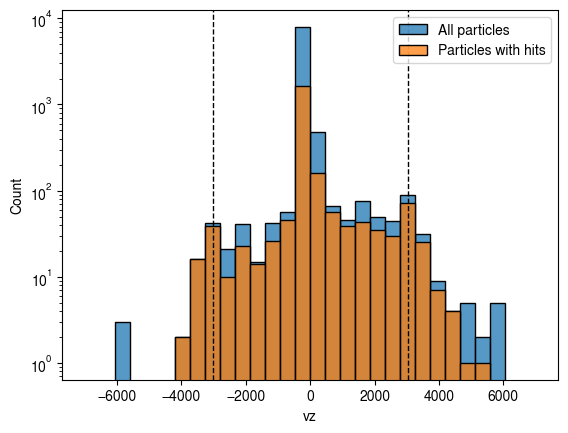

In [113]:
sns.histplot(particles_df.vz, bins = 30, binrange=(-7000, 7000), label="All particles")
sns.histplot(particles_with_hits.vz, bins = 30, binrange=(-7000, 7000), label="Particles with hits")
plt.axvline(detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.axvline(-detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


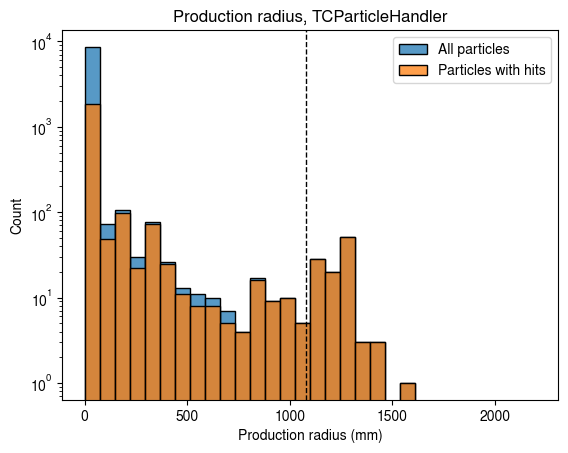

In [114]:
sns.histplot(np.sqrt(particles_df.vx**2 + particles_df.vy**2), bins = 30, binrange=(0, 2200), label="All particles")
sns.histplot(np.sqrt(particles_with_hits.vx**2 + particles_with_hits.vy**2), bins = 30, binrange=(0, 2200), label="Particles with hits")
plt.axvline(detector_params['tracking_radius'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.title("Production radius, TCParticleHandler")
plt.xlabel("Production radius (mm)")
plt.legend()
plt.show()


## 2. Load in new large-tracker edm4hep file

In [55]:
edm4hep_file = f"{base_dir}/low_threshold_large_tracker/edm4hep.root"

event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [56]:
tracker_df = event["tracker_df"]
tracker_df.columns

Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
       'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [57]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [58]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [59]:
hits_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
0,18428729469050290192,6.279467e-07,737.476990,-1083.676514,-331.500000,0,1,1310.811523,1352.079590,-0.973256,1.818499,-0.250276,ECalBarrelCollection
1,18300095628031993872,2.059417e-04,-1205.247070,-521.310486,-2657.100098,1,2,1313.158447,2963.876953,-2.733358,2.682590,-1.454070,ECalBarrelCollection
2,18300658513560807440,1.595900e-05,-1220.525635,-444.836060,-2652.000000,2,3,1299.062012,2953.077393,-2.792092,2.686104,-1.462030,ECalBarrelCollection
3,28710275835123728,2.549791e-04,719.923035,1204.970337,515.099976,3,14,1403.653320,1495.182495,1.032246,1.219083,0.359197,ECalBarrelCollection
4,28710280130091024,6.176600e-05,715.211243,1206.921997,515.099976,14,17,1402.921143,1494.495239,1.035842,1.218915,0.359377,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173370,19421781989294356,7.089448e-05,-344.989838,2041.930908,3647.500000,744773,744774,2070.869141,4194.372070,1.738168,0.516369,1.331509,HCalEndcapCollection
173371,16044086563733780,1.605069e-05,-245.333771,1694.700928,3647.500000,744774,744776,1712.366821,4029.448486,1.714563,0.438921,1.500346,HCalEndcapCollection
173372,16044095153701140,1.264276e-03,-186.486664,1706.406372,3698.500000,744776,744779,1716.566284,4077.438232,1.679651,0.434538,1.510708,HCalEndcapCollection
173373,15199674518503700,1.098509e-04,-139.504974,1623.988403,3647.500000,744779,744780,1629.969360,3995.129150,1.656489,0.420251,1.545180,HCalEndcapCollection


In [60]:
contrib_df = event["calo_contrib_df"]


In [61]:
contrib_df

,PDG,energy,time,step_x,step_y,step_z,particle_id,detector
0,0,6.279467e-07,1350.525146,0.0,0.0,0.0,8352,ECalBarrelCollection
1,0,2.059417e-04,383.534698,0.0,0.0,0.0,8448,ECalBarrelCollection
2,0,1.595900e-05,383.797821,0.0,0.0,0.0,8448,ECalBarrelCollection
3,0,1.699067e-05,741.755615,0.0,0.0,0.0,8448,ECalBarrelCollection
4,0,1.674378e-05,741.755798,0.0,0.0,0.0,8448,ECalBarrelCollection
...,...,...,...,...,...,...,...,...
744778,0,5.990888e-04,22.056133,0.0,0.0,0.0,10162,HCalEndcapCollection
744779,0,1.098509e-04,21.878006,0.0,0.0,0.0,10162,HCalEndcapCollection
744780,0,4.976119e-04,22.492050,0.0,0.0,0.0,10162,HCalEndcapCollection
744781,0,3.711279e-05,22.564148,0.0,0.0,0.0,10162,HCalEndcapCollection


In [62]:
# Get contribs and tracker hits
particles_with_hits = np.concatenate([contrib_df.particle_id.unique(), tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits

array([   81,    82,    83, ..., 10181, 10182, 10183], dtype=int32)

In [63]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max'])]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
431,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.135754,...,3357.657613,-10000.000000,913,914,1046,1046,0.169181,0.462928,-1.664549,2.502134
432,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.028816,...,4744.760131,-10000.000000,914,915,1046,1046,0.130022,0.214030,-1.083045,1.794279
1367,22,1,150994944,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.269879,...,586.819899,2048.353858,4509,4510,4833,4833,0.323424,0.705943,1.416553,2.557915
1368,22,1,150994944,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.485722,...,547.870862,2021.524967,4510,4511,4833,4833,0.502281,1.020187,1.334736,2.884102
1369,22,1,150994944,0.0,15.535490,0.000000,-1057.864047,753.356960,1686.353161,-0.804957,...,757.137901,1693.818546,4511,4512,4833,4834,1.049465,1.693831,1.058093,2.444975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10179,11,0,1224736768,-1.0,18.186077,0.000511,-237.740016,1166.770183,2676.779374,-0.366047,...,1257.977987,2899.778293,29639,29640,29641,29642,1.832190,4.657948,1.585070,1.771936
10180,-11,0,1224736768,1.0,18.186077,0.000511,-237.740016,1166.770183,2676.779374,-0.288590,...,1264.598842,2915.808315,29640,29641,29642,29643,1.445733,3.673890,1.584605,1.771761
10181,22,0,1493172224,0.0,18.929773,0.000000,-255.238089,1253.142608,2881.577308,-0.095105,...,1254.523182,2884.844369,29641,29642,29643,29643,0.492755,1.245752,1.578998,1.765021
10182,22,0,1493172224,0.0,18.242474,0.000000,-239.087501,1173.294134,2692.319134,-0.156753,...,1252.793818,2882.152920,29642,29643,29643,29644,0.777484,1.977635,1.585648,1.773804


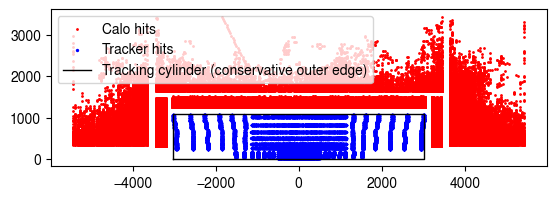

In [64]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


In [65]:
particles_df.loc[particles_with_hits].vz.describe()

count    3109.000000
mean      506.997821
std      1992.617843
min     -4949.573343
25%      -116.807617
50%        -8.399927
75%      1661.250164
max      5422.410420
Name: vz, dtype: float64

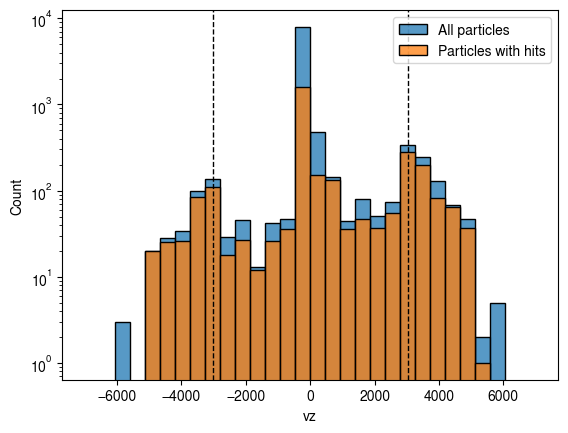

In [66]:
sns.histplot(particles_df.vz, bins = 30, binrange=(-7000, 7000), label="All particles")
sns.histplot(particles_df.loc[particles_with_hits].vz, bins = 30, binrange=(-7000, 7000), label="Particles with hits")
plt.axvline(detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.axvline(-detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


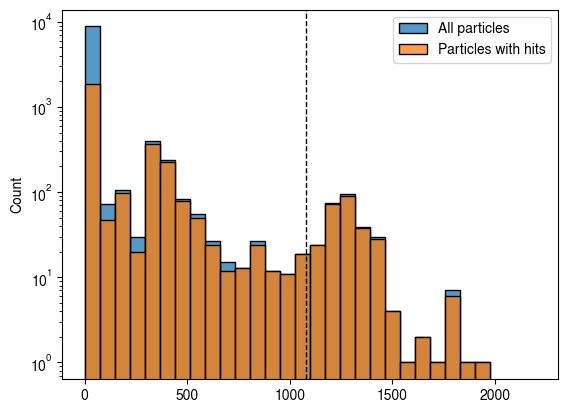

In [67]:
sns.histplot(np.sqrt(particles_df.vx**2 + particles_df.vy**2), bins = 30, binrange=(0, 2200), label="All particles")
sns.histplot(np.sqrt(particles_df.loc[particles_with_hits].vx**2 + particles_df.loc[particles_with_hits].vy**2), bins = 30, binrange=(0, 2200), label="Particles with hits")
plt.axvline(detector_params['tracking_radius'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


## 3. Load in new realistic-tracker edm4hep file

Set z_max to 3030, r_max to 1080

In [62]:
edm4hep_file = f"{base_dir}/low_threshold_realistic_tracker/edm4hep.root"

event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [63]:
tracker_df = event["tracker_df"]
tracker_df.columns

Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
       'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [64]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [65]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [66]:
contrib_df = event["calo_contrib_df"]


In [67]:
# Get contribs and tracker hits
particles_with_hits = np.concatenate([contrib_df.particle_id.unique(), tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits

array([  81,   82,   83, ..., 9128, 9129, 9130], dtype=int32)

In [68]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max'])]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
431,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.135754,...,3357.657613,-10000.000000,913,914,1043,1043,0.169181,0.462928,-1.664549,2.502134
432,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.028816,...,4744.760131,-10000.000000,914,915,1043,1043,0.130022,0.214030,-1.083045,1.794279
1367,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.269879,...,586.819899,2048.353858,4509,4510,4782,4782,0.323424,0.705943,1.416553,2.557915
1368,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.485722,...,547.870862,2021.524967,4510,4511,4782,4782,0.502281,1.020187,1.334736,2.884102
1369,22,1,83886080,0.0,15.535490,0.000000,-1057.864047,753.356960,1686.353161,-0.804957,...,757.137901,1693.818546,4511,4512,4782,4782,1.049465,1.693831,1.058093,2.444975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9119,2212,0,2030043136,1.0,18.847214,0.938272,-272.137866,1251.617539,2851.319139,0.118233,...,658.987241,2242.344725,28579,28580,28589,28589,0.495659,0.592931,-0.616677,-1.329937
9120,2112,0,2013265920,0.0,31.043116,0.939565,-240.135307,1149.269292,3240.537294,0.002847,...,381.543123,1350.000000,28580,28581,28589,28589,0.013168,0.013823,0.313994,1.352887
9127,22,0,2030043136,0.0,21.632509,0.000000,-539.536353,483.901875,3201.495043,0.000127,...,296.344487,-2542.609208,28587,28588,28590,28590,0.000328,0.000511,-1.013309,-1.172824
9129,11,0,2030043136,-1.0,19.328438,0.000511,-454.786562,1165.726570,3018.535546,0.000587,...,907.034224,2643.817965,28589,28590,28591,28591,0.003817,0.012957,1.892916,1.416392


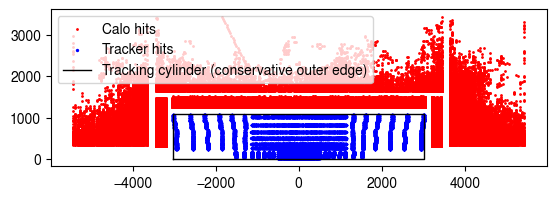

In [69]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


In [70]:
particles_df.loc[particles_with_hits].vz.describe()

count    2287.000000
mean      104.137837
std      1074.817924
min     -3811.187972
25%      -116.807723
50%       -41.525064
75%        -2.343601
max      5422.410420
Name: vz, dtype: float64

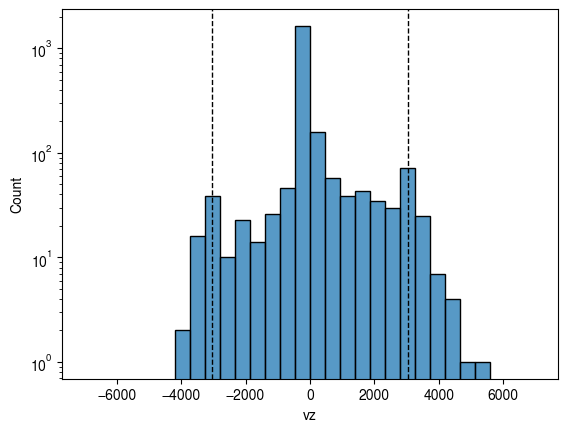

In [71]:
sns.histplot(particles_df.loc[particles_with_hits].vz, bins = 30, binrange=(-7000, 7000))
plt.axvline(detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.axvline(-detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.show()


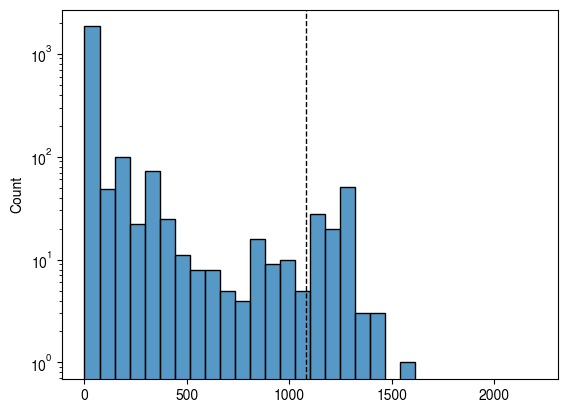

In [72]:
sns.histplot(np.sqrt(particles_df.loc[particles_with_hits].vx**2 + particles_df.loc[particles_with_hits].vy**2), bins = 30, binrange=(0, 2200))
plt.axvline(detector_params['tracking_radius'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.show()


## 4. Load in TV handled edm4hep file

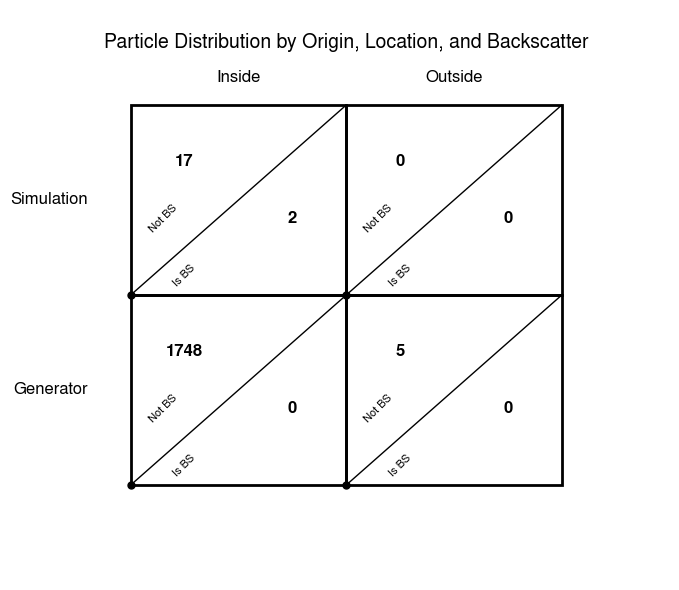

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1748 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |            17 |          2
Outside   | Simulation |             0 |          0

Totals by Category:
Total particles: 1772
From Generator: 1753
From Simulation: 19
Inside Tracker: 1767
Outside Tracker: 5
Backscatter: 2


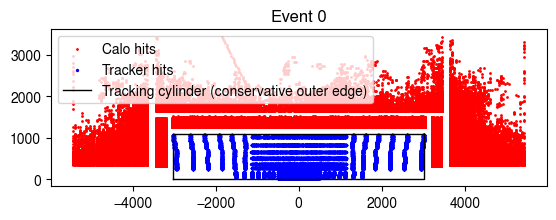

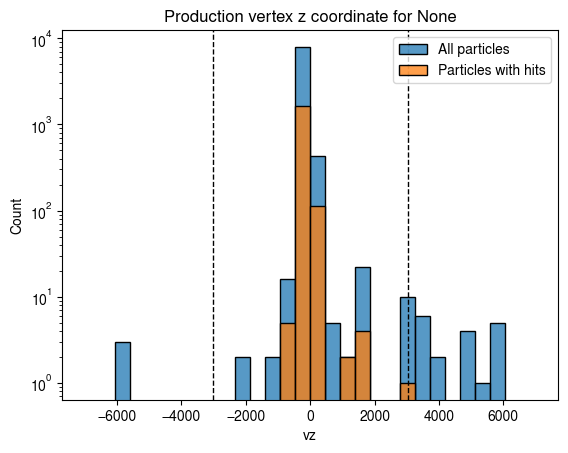

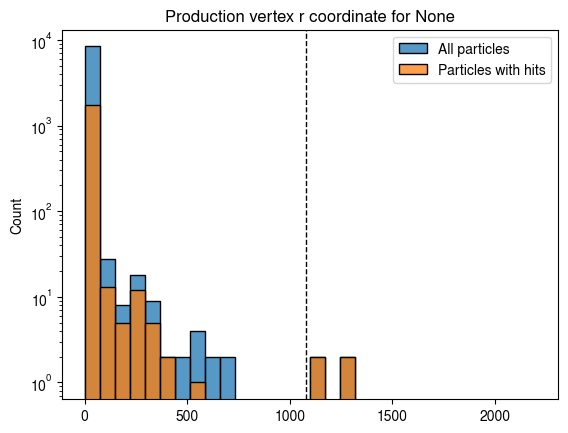

In [7]:
edm4hep_file = f"{base_dir}/low_threshold_tv/edm4hep.root"
event = event_diagnostics(edm4hep_file, event_num=event_num, detector_params=detector_params)

In [80]:
tracker_df = event["tracker_df"]
tracker_df.columns, len(tracker_df)

(Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
        'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
        'detector'],
       dtype='object'),
 21553)

In [81]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [82]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [83]:
contrib_df = event["calo_contrib_df"]


In [90]:
# Get contribs and tracker hits
particles_with_hits = np.concatenate([contrib_df.particle_id.unique(), tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits

array([  81,   82,   83, ..., 8466, 8467, 8468], dtype=int32)

In [91]:
particles_with_hits = particles_df.loc[particles_with_hits]

In [92]:
particles_with_hits["created_in_simulation"] = particles_with_hits.simulatorStatus.apply(lambda x: get_simulator_status_bits(x)["created_in_simulation"]).astype(int)
particles_with_hits["backscatter"] = particles_with_hits.simulatorStatus.apply(lambda x: get_simulator_status_bits(x)["backscatter"]).astype(int)
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_with_hits["created_outside_tracker"] = ((particles_with_hits.vx**2 + particles_with_hits.vy**2) > detector_params['tracking_radius']**2) | (particles_with_hits.vz > detector_params['tracking_z_max']).astype(int)

In [93]:
particles_with_hits

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,parents_end,daughters_begin,daughters_end,pt,p,eta,phi,created_in_simulation,backscatter,created_outside_tracker
81,-2112,1,150994944,0.0,8.091558,0.939570,0.003543,-0.005813,-105.372111,0.253307,...,89,233,233,0.267853,1.071615,-2.063633,-0.331065,0,0,False
82,-211,1,134217728,-1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,-0.166478,...,91,233,233,0.207967,0.704552,-1.890799,2.498928,0,0,False
83,211,1,83886080,1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,-0.183526,...,93,233,233,0.490934,2.525152,2.321307,1.953931,0,0,False
85,-321,1,67108864,-1.0,8.091558,0.493680,0.003543,-0.005813,-105.372111,-0.520439,...,97,234,234,0.555004,7.124353,3.243925,-2.786807,0,0,False
92,-211,1,83886080,-1.0,8.091558,0.139570,0.003543,-0.005813,-105.372111,0.079074,...,109,251,251,0.088126,0.113962,0.748153,-0.457230,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,-11,0,1157627904,1.0,9.263218,0.000511,-23.001159,-67.528747,238.563238,-0.085198,...,27925,27928,27928,0.266295,1.324149,2.286799,-1.896463,1,0,False
8465,11,0,1157627904,-1.0,9.255639,0.000511,34.746975,-9.403114,241.749926,0.121091,...,27926,27928,27928,0.125529,1.217592,2.962574,-0.266687,1,0,False
8466,-11,0,1157627904,1.0,9.255639,0.000511,34.746975,-9.403114,241.749926,3.556171,...,27927,27928,27929,3.683705,35.716476,2.962170,-0.263904,1,0,False
8467,22,0,1426063360,0.0,9.268609,0.000000,35.133712,-9.507199,245.617447,0.309178,...,27928,27929,27929,0.320132,3.106907,2.963132,-0.262346,1,0,False


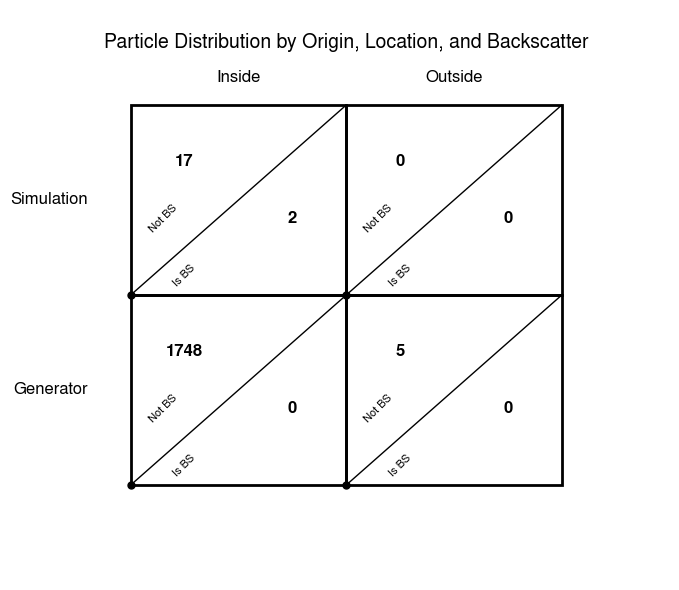

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1748 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |            17 |          2
Outside   | Simulation |             0 |          0

Totals by Category:
Total particles: 1772
From Generator: 1753
From Simulation: 19
Inside Tracker: 1767
Outside Tracker: 5
Backscatter: 2


In [94]:
# Call the function with the current DataFrame
plot_particle_distribution(particles_with_hits)

In [95]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max'])]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
431,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.135754,...,3357.657613,-10000.000000,913,914,1017,1017,0.169181,0.462928,-1.664549,2.502134
432,22,1,33554432,0.0,35.082127,0.000000,-1967.082055,2722.243191,-7288.018882,-0.028816,...,4744.760131,-10000.000000,914,915,1017,1017,0.130022,0.214030,-1.083045,1.794279
1367,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.269879,...,586.819899,2048.353858,4509,4510,4707,4707,0.323424,0.705943,1.416553,2.557915
1368,22,1,83886080,0.0,15.535490,0.000000,-1004.020980,515.637317,1797.751103,-0.485722,...,547.870862,2021.524967,4510,4511,4707,4707,0.502281,1.020187,1.334736,2.884102
1369,22,1,83886080,0.0,15.535490,0.000000,-1057.864047,753.356960,1686.353161,-0.804957,...,757.137901,1693.818546,4511,4512,4707,4707,1.049465,1.693831,1.058093,2.444975
1370,22,1,83886080,0.0,15.535490,0.000000,-1057.864047,753.356960,1686.353161,-0.047907,...,754.892300,1691.053821,4512,4513,4707,4707,0.049326,0.061046,0.676390,2.901123
2576,211,1,33554432,1.0,15.868302,0.139570,-8.084839,-0.219698,4057.218535,-0.067063,...,4.848590,10000.000000,9666,9667,9699,9699,0.102163,91.489796,7.490559,2.286878
2577,-211,1,33554432,-1.0,15.868302,0.139570,-8.084839,-0.219698,4057.218535,-0.850237,...,-1.857930,10000.000000,9667,9668,9699,9699,0.856323,370.791573,6.763894,-3.022307
3486,2212,1,33554432,1.0,14.681981,0.938270,-3.070969,-0.027746,5935.150640,-0.385027,...,-0.248074,10000.000000,11991,11992,12029,12029,0.388063,871.427734,8.409867,-3.016416
3487,-211,1,33554432,-1.0,14.681981,0.139570,-3.070969,-0.027746,5935.150640,-0.111807,...,1.919927,10000.000000,11992,11993,12029,12029,0.120009,93.324416,7.349420,2.769741


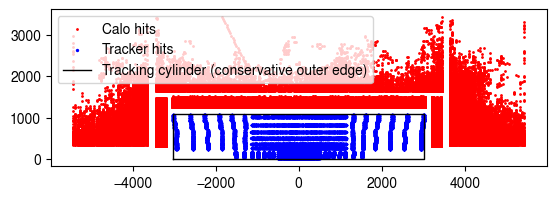

In [96]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


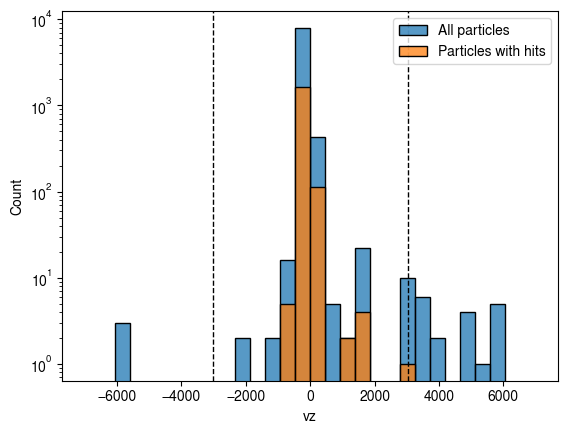

In [98]:
sns.histplot(particles_df.vz, bins = 30, binrange=(-7000, 7000), label="All particles")
sns.histplot(particles_with_hits.vz, bins = 30, binrange=(-7000, 7000), label="Particles with hits")
plt.axvline(detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.axvline(-detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


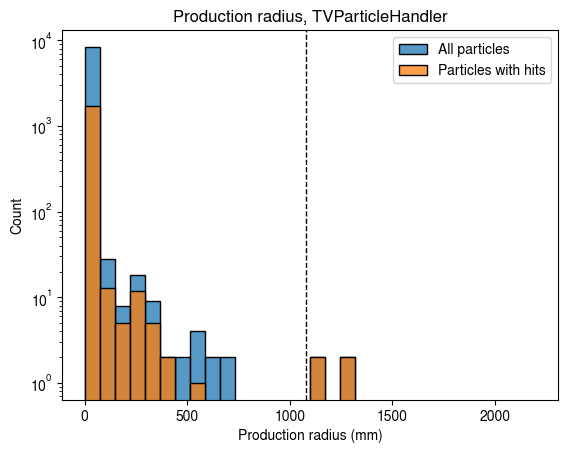

In [99]:
sns.histplot(np.sqrt(particles_df.vx**2 + particles_df.vy**2), bins = 30, binrange=(0, 2200), label="All particles")
sns.histplot(np.sqrt(particles_with_hits.vx**2 + particles_with_hits.vy**2), bins = 30, binrange=(0, 2200), label="Particles with hits")
plt.axvline(detector_params['tracking_radius'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.title("Production radius, TVParticleHandler")
plt.xlabel("Production radius (mm)")
plt.legend()
plt.show()


## 5. Load in handled TV disconnected edm4hep file

In [37]:
edm4hep_file = f"{base_dir}/low_threshold_tv_disconnected/edm4hep.root"

event = load_edm4hep_file(edm4hep_file, event_num=event_num)

In [38]:
tracker_df = event["tracker_df"]
tracker_df.columns, len(tracker_df)

(Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
        'pz', 'EDep', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
        'detector'],
       dtype='object'),
 21553)

In [39]:
parents_df = event["parents_df"]

daughters_df = event["daughters_df"]

particles_df = event["particles_df"]

# Create a column from the index
particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [40]:
hits_df = event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [41]:
contrib_df = event["calo_contrib_df"]


In [42]:
# Get contribs and tracker hits
particles_with_hits = np.concatenate([contrib_df.particle_id.unique(), tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits

array([  81,   82,   83, ..., 8701, 8702, 8703], dtype=int32)

In [43]:
particles_with_hits = particles_df.loc[particles_with_hits]

In [44]:
particles_with_hits["created_in_simulation"] = particles_with_hits.simulatorStatus.apply(lambda x: get_simulator_status_bits(x)["created_in_simulation"]).astype(int)
particles_with_hits["backscatter"] = particles_with_hits.simulatorStatus.apply(lambda x: get_simulator_status_bits(x)["backscatter"]).astype(int)
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_with_hits["created_outside_tracker"] = ((particles_with_hits.vx**2 + particles_with_hits.vy**2) > detector_params['tracking_radius']**2) | (particles_with_hits.vz > detector_params['tracking_z_max']).astype(int)

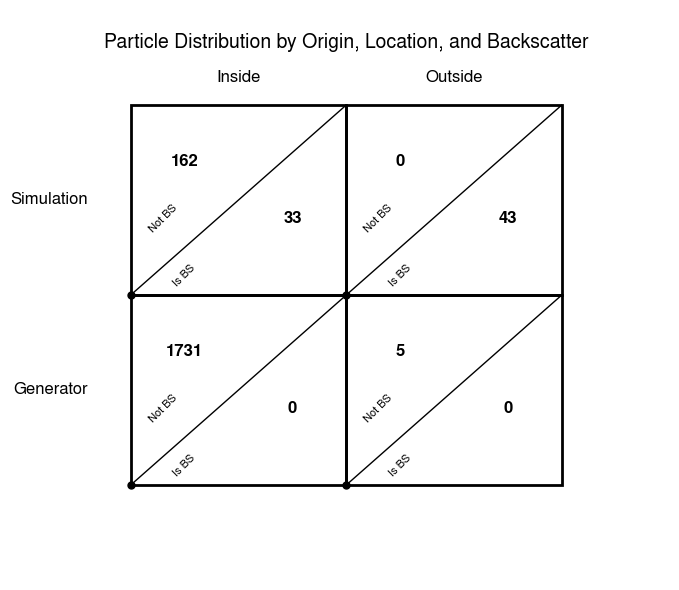

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1731 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |           162 |         33
Outside   | Simulation |             0 |         43

Totals by Category:
Total particles: 1974
From Generator: 1736
From Simulation: 238
Inside Tracker: 1926
Outside Tracker: 48
Backscatter: 76


In [ ]:
plot_particle_distribution(particles_with_hits)

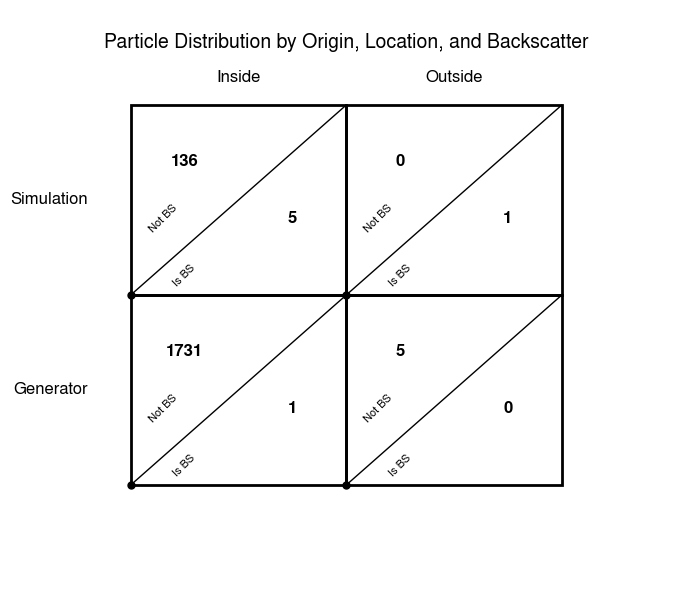

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1731 |          1
Outside   | Generator  |             5 |          0
Inside    | Simulation |           136 |          5
Outside   | Simulation |             0 |          1

Totals by Category:
Total particles: 1879
From Generator: 1737
From Simulation: 142
Inside Tracker: 1873
Outside Tracker: 6
Backscatter: 7


In [ ]:
plot_particle_distribution(particles_with_hits)

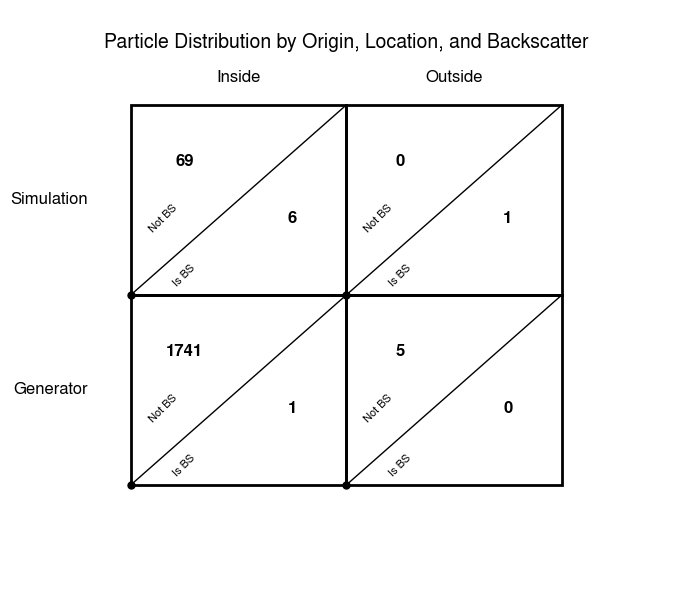

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1741 |          1
Outside   | Generator  |             5 |          0
Inside    | Simulation |            69 |          6
Outside   | Simulation |             0 |          1

Totals by Category:
Total particles: 1823
From Generator: 1747
From Simulation: 76
Inside Tracker: 1817
Outside Tracker: 6
Backscatter: 8


In [ ]:
plot_particle_distribution(particles_with_hits)

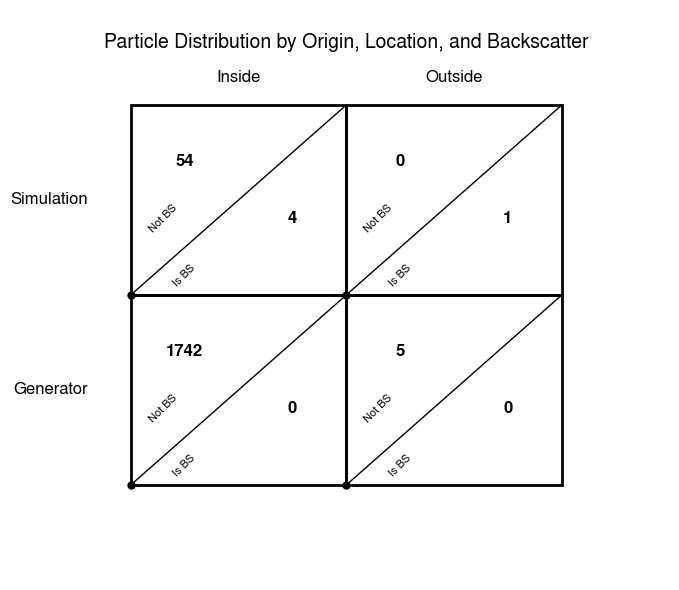

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1742 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |            54 |          4
Outside   | Simulation |             0 |          1

Totals by Category:
Total particles: 1806
From Generator: 1747
From Simulation: 59
Inside Tracker: 1800
Outside Tracker: 6
Backscatter: 5


In [ ]:
plot_particle_distribution(particles_with_hits)

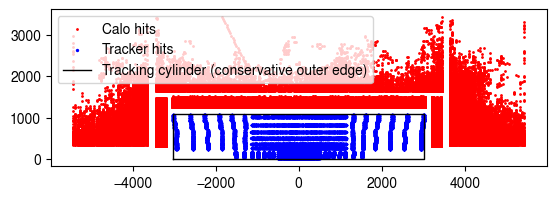

In [25]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


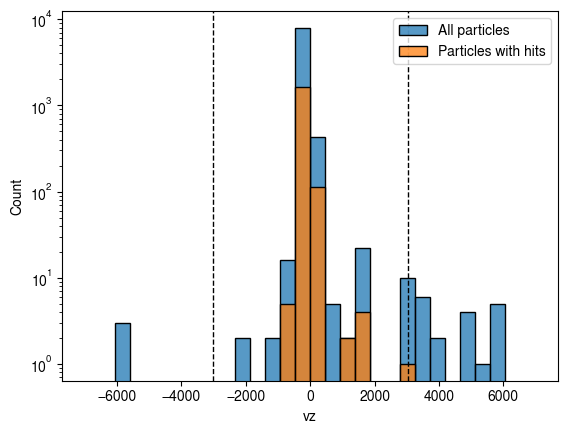

In [27]:
sns.histplot(particles_df.vz, bins = 30, binrange=(-7000, 7000), label="All particles")
sns.histplot(particles_with_hits.vz, bins = 30, binrange=(-7000, 7000), label="Particles with hits")
plt.axvline(detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.axvline(-detector_params['tracking_z_max'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


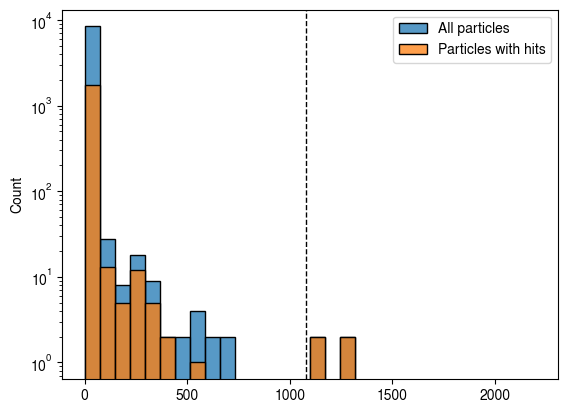

In [28]:
sns.histplot(np.sqrt(particles_df.vx**2 + particles_df.vy**2), bins = 30, binrange=(0, 2200), label="All particles")
sns.histplot(np.sqrt(particles_with_hits.vx**2 + particles_with_hits.vy**2), bins = 30, binrange=(0, 2200), label="Particles with hits")
plt.axvline(detector_params['tracking_radius'], color="black", linestyle="--", lw=1)
plt.yscale('log')
plt.legend()
plt.show()


## Visualise Tracker Hits

In [14]:
tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector
0,2815394012594182,0.143050,0.167380,0,31.313939,7.240239,-28.260180,7.319360,1.682778,-6.602227,0.000046,0,32.140066,42.797448,0.227222,2.292046,-0.793388,7.510312,PixelBarrelReadout
1,2480042966122758,0.147953,0.173594,0,32.448207,7.500762,-29.283262,7.319657,1.681203,-6.601789,0.000042,0,33.303868,44.347007,0.227171,2.292043,-0.793383,7.510248,PixelBarrelReadout
2,63789459870974230,0.302190,0.167145,0,66.250578,15.215565,-59.748868,7.324624,1.661593,-6.599767,0.000062,0,67.975382,90.501822,0.225752,2.291875,-0.793160,7.510726,PixelBarrelReadout
3,2884963892789798,0.508585,0.168126,0,111.588953,25.423328,-100.590262,7.329116,1.636143,-6.599785,0.000046,0,114.448417,152.370735,0.224007,2.291839,-0.793111,7.509521,PixelBarrelReadout
4,11012433586160438,0.758126,0.168246,0,166.447468,37.540911,-149.978514,7.334657,1.602737,-6.600558,0.000055,0,170.628485,227.173137,0.221830,2.291874,-0.793159,7.507726,PixelBarrelReadout
5,2480042966122758,0.148354,0.498892,1073741824,32.454890,7.383940,-29.426873,-0.000176,-0.000322,-0.000460,0.000168,0,33.284267,44.427281,0.223706,2.294761,-0.797007,0.000367,PixelBarrelReadout
6,2215996966699270,0.158897,0.383476,1073741824,33.291289,5.875622,-29.924332,0.000235,-0.000144,-0.000107,0.000212,0,33.805811,45.147520,0.174692,2.295365,-0.797813,0.000276,PixelBarrelReadout
7,2180761055002886,0.166418,0.046271,1073741824,33.629940,5.299608,-30.100002,0.000093,0.000012,-0.000094,0.000065,0,34.044952,45.443028,0.156301,2.294771,-0.797021,0.000094,PixelBarrelReadout
8,71565940542144777,1.168205,0.271665,0,256.684054,56.904351,-231.099534,7.345234,1.548243,-6.598343,0.000071,0,262.915973,350.045431,0.218162,2.291880,-0.793166,7.506631,ShortStripBarrelReadout
9,351633267950105,1.597078,0.268385,0,351.246436,76.453148,-315.975668,7.355786,1.491108,-6.597908,0.000107,0,359.470642,478.601886,0.214320,2.291889,-0.793178,7.505397,ShortStripBarrelReadout


In [15]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1400,    # in mm
    'tracking_z_max': 3400,     # in mm
    'energy_threshold': 1.0     # in GeV
}


In [16]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max'])]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi


In [32]:
contrib_df

,PDG,energy,time,step_x,step_y,step_z,particle_id,detector
0,0,1.932579e-03,6.529276,0.0,0.0,0.0,26,ECalBarrelCollection
1,0,2.622566e-03,6.621058,0.0,0.0,0.0,26,ECalBarrelCollection
2,0,4.704779e-06,55.656937,0.0,0.0,0.0,25,ECalBarrelCollection
3,0,5.337775e-05,4669.966797,0.0,0.0,0.0,25,ECalBarrelCollection
4,0,3.149147e-05,4669.967285,0.0,0.0,0.0,25,ECalBarrelCollection
...,...,...,...,...,...,...,...,...
2215,0,7.465495e-09,1670.053589,0.0,0.0,0.0,2,HCalBarrelCollection
2216,0,1.709679e-09,1812.748169,0.0,0.0,0.0,2,HCalBarrelCollection
2217,0,5.848196e-10,1879.912109,0.0,0.0,0.0,2,HCalBarrelCollection
2218,0,5.219031e-03,8.166033,0.0,0.0,0.0,2,HCalBarrelCollection


In [33]:
particles_in_calo = contrib_df.particle_id.unique()

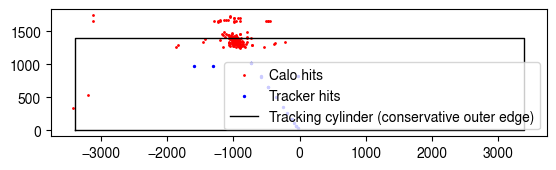

In [ ]:
plt.scatter(hits_df.z, hits_df.r, c="red", s=1, label="Calo hits")
plt.scatter(tracker_df.z, tracker_df.r, c="blue", s=2, label="Tracker hits")

tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']

plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


In [35]:
# Check if any particles have vx, vy, vz that are outside the tracking cylinder AND interacted in the calo
particles_df[((particles_df.vx**2 + particles_df.vy**2) > detector_params['tracking_radius']**2) | (particles_df.vz > detector_params['tracking_z_max']) & (particles_df.index.isin(particles_in_calo))]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi


In [36]:
particles_in_calo

array([26, 25, 24, 16, 10, 49, 48,  8, 57, 56,  6,  5,  3,  2,  4],
      dtype=int32)

In [23]:
# Let's visualise the FULL story of particle 372721
particles_df.loc[372721]

PDG                2.110000e+02
generatorStatus    0.000000e+00
simulatorStatus    1.224737e+09
charge             1.000000e+00
time               1.942762e+01
mass               1.395701e-01
vx                 3.166354e+02
vy                -1.011527e+02
vz                 3.276783e+03
px                 4.236736e+00
py                -1.814437e+00
pz                 4.694481e+01
endpoint_x         3.190526e+02
endpoint_y        -1.021897e+02
endpoint_z         3.303600e+03
parents_begin      3.921810e+05
parents_end        3.921820e+05
daughters_begin    3.928510e+05
daughters_end      3.928550e+05
pt                 4.608917e+00
p                  4.717051e+01
eta                3.016528e+00
phi               -4.046311e-01
Name: 372721, dtype: float64

In [28]:
hits_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
0,18314450877613664272,2.416614e-05,1137.549927,526.390564,-2397.000000,0,1,1253.437988,2704.942871,0.433398,2.659778,-1.403731,ECalBarrelCollection
1,18335561230284775440,6.632625e-05,1158.841919,776.580017,-2019.599976,1,2,1394.987915,2454.541748,0.590400,2.537119,-1.165429,ECalBarrelCollection
2,18387071477439805456,7.453639e-05,-1234.614624,384.429535,-1081.199951,2,3,1293.081299,1685.542236,2.839732,2.267190,-0.760642,ECalBarrelCollection
3,74309376680323088,4.671832e-05,1183.535889,468.155792,1341.300049,3,5,1272.763550,1849.057373,0.376670,0.759186,0.918942,ECalBarrelCollection
4,18371871901711632400,2.835334e-07,667.744141,-1078.999268,-1356.599976,5,6,1268.905640,1857.548096,-1.016628,2.389583,-0.929408,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178287,19984762007650580,4.246452e-09,-150.730362,2141.747070,3902.500000,761503,761504,2147.044434,4454.133789,1.641058,0.502975,1.358963,HCalEndcapCollection
178288,19703287030939924,6.907979e-09,-144.877655,2112.323486,3902.500000,761504,761505,2117.285889,4439.865723,1.639276,0.497102,1.371212,HCalEndcapCollection
178289,19140315602813204,3.094865e-04,-280.290009,2024.212769,4106.500000,761505,761507,2043.526245,4586.866211,1.708390,0.461752,1.447883,HCalEndcapCollection
178290,18577369944359188,5.468227e-05,-239.161041,1971.218384,4106.500000,761507,761508,1985.673706,4561.385742,1.691533,0.450396,1.473667,HCalEndcapCollection


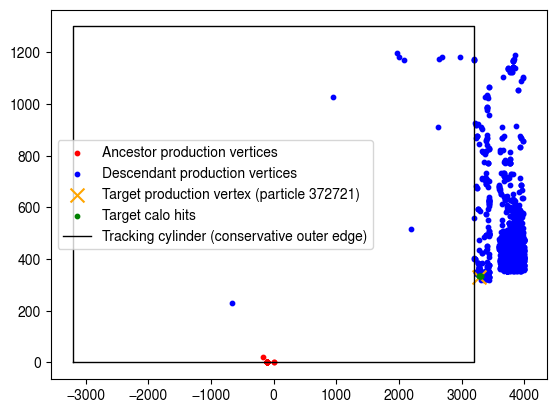

In [27]:
# Given decay tree G, find all ancestors and descendants of particle 372721, and plot them on the decay tree
target_particleID = 372721

# Find all ancestors and descendants of particle 372721
ancestors = nx.ancestors(G, target_particleID)
descendants = nx.descendants(G, target_particleID)
ancestors_df = particles_df.loc[list(ancestors)]
descendants_df = particles_df.loc[list(descendants)]
# Plot the decay tree, highlighting the ancestors and descendants
plt.scatter(ancestors_df.vz, np.sqrt(ancestors_df.vx**2 + ancestors_df.vy**2), c="red", s=10, label="Ancestor production vertices")
plt.scatter(descendants_df.vz, np.sqrt(descendants_df.vx**2 + descendants_df.vy**2), c="blue", s=10, label="Descendant production vertices")
plt.scatter(particles_df[particles_df.index == target_particleID].vz, np.sqrt(particles_df[particles_df.index == target_particleID].vx**2 + particles_df[particles_df.index == target_particleID].vy**2), c="orange", s=100, marker="x", label=f"Target production vertex (particle {target_particleID})")
plt.scatter(contrib_df[contrib_df.particle_id == target_particleID].z, np.sqrt(contrib_df[contrib_df.particle_id == target_particleID].x**2 + contrib_df[contrib_df.particle_id == target_particleID].y**2), c="green", s=10, label="Target calo hits")

# add tracking cylinder
tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']
plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")

# let's add a legend
plt.legend()

plt.show()
